# Google Play Store — Data Cleaning & EDA
**Dataset:** 9,659 apps · 64,295 user reviews  
**Goal:** Clean raw Play Store data, engineer features, and extract market-level insights  
**Tools:** Python · Pandas · Matplotlib · Seaborn · SciPy


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, ttest_ind
import warnings

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)


## 2. Load Data

In [3]:
import pandas as pd

apps = pd.read_csv(r"C:\Users\sudhe\Desktop\Oasis Infobyte\data\apps.csv")
reviews = pd.read_csv(r"C:\Users\sudhe\Desktop\Oasis Infobyte\data\user_reviews.csv")

# Drop unnamed index column carried over from original file
apps.drop(columns=['Unnamed: 0'], errors='ignore', inplace=True)

print("Apps shape   :", apps.shape)
print("Reviews shape:", reviews.shape)

Apps shape   : (9659, 13)
Reviews shape: (64295, 5)


In [4]:
apps.head(3)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.10,159,19.00,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.90,967,14.00,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.70,87510,8.70,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up


In [5]:
reviews.head(3)


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.53
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.29
2,10 Best Foods for You,NaN,NaN,NaN,NaN


## 3. Data Quality Assessment
Assess missing values, data types, and obvious anomalies before touching anything.


In [6]:
quality_report = pd.DataFrame({
    'Missing Count': apps.isnull().sum(),
    'Missing %'    : (apps.isnull().sum() / len(apps) * 100).round(2),
    'Dtype'        : apps.dtypes,
    'Unique Values': apps.nunique()
})
quality_report


,Missing Count,Missing %,Dtype,Unique Values
App,0,0.00,object,9659
Category,0,0.00,object,33
Rating,1463,15.15,float64,39
Reviews,0,0.00,int64,5330
Size,1227,12.70,float64,191
Installs,0,0.00,object,21
Type,0,0.00,object,2
Price,0,0.00,object,92
Content Rating,0,0.00,object,6
Genres,0,0.00,object,118


In [7]:
# Reviews dataset quality
quality_reviews = pd.DataFrame({
    'Missing Count': reviews.isnull().sum(),
    'Missing %'    : (reviews.isnull().sum() / len(reviews) * 100).round(2),
    'Dtype'        : reviews.dtypes,
    'Unique Values': reviews.nunique()
})
quality_reviews


,Missing Count,Missing %,Dtype,Unique Values
App,0,0.00,object,1074
Translated_Review,26868,41.79,object,27994
Sentiment,26863,41.78,object,3
Sentiment_Polarity,26863,41.78,float64,5410
Sentiment_Subjectivity,26863,41.78,float64,4474


In [8]:
print("Duplicate rows in apps   :", apps.duplicated().sum())
print("Duplicate rows in reviews:", reviews.duplicated().sum())


Duplicate rows in apps   : 0
Duplicate rows in reviews: 33616


## 4. Data Cleaning

### 4.1 Clean `Installs`

In [9]:
apps['Installs'] = (
    apps['Installs']
    .str.replace(',', '', regex=False)
    .str.replace('+', '', regex=False)
)
apps['Installs'] = pd.to_numeric(apps['Installs'], errors='coerce')
print("Installs — nulls after conversion:", apps['Installs'].isnull().sum())
print("Sample:", apps['Installs'].dropna().unique()[:8])


Installs — nulls after conversion: 0
Sample: [   10000   500000  5000000 50000000   100000    50000  1000000 10000000]


### 4.2 Clean `Price`

In [10]:
apps['Price'] = (
    apps['Price']
    .str.replace('$', '', regex=False)
)
apps['Price'] = pd.to_numeric(apps['Price'], errors='coerce')
apps['Price'] = apps['Price'].fillna(0)
print("Price — nulls:", apps['Price'].isnull().sum())
print("Max price: $", apps['Price'].max())


Price — nulls: 0
Max price: $ 400.0


### 4.3 Impute `Rating` (median per category)

In [11]:
# Category-level median is more accurate than a global median
apps['Rating'] = apps.groupby('Category')['Rating'].transform(
    lambda x: x.fillna(x.median())
)

# Safety fallback: fill any remaining nulls with global median
apps['Rating'] = apps['Rating'].fillna(apps['Rating'].median())

print("Rating nulls after imputation:", apps['Rating'].isnull().sum())


Rating nulls after imputation: 0


### 4.4 Parse `Last Updated` → datetime

In [12]:
apps['Last Updated'] = pd.to_datetime(apps['Last Updated'], errors='coerce')
print("Last Updated — nulls:", apps['Last Updated'].isnull().sum())
print("Date range:", apps['Last Updated'].min(), "→", apps['Last Updated'].max())


Last Updated — nulls: 0
Date range: 2010-05-21 00:00:00 → 2018-08-08 00:00:00


### 4.5 Clean Reviews Dataset

In [13]:
# Drop rows with no review text (42% of dataset — no useful information)
reviews_clean = reviews.dropna(subset=['Translated_Review']).copy()

# Fill remaining sentiment nulls
reviews_clean['Sentiment'] = reviews_clean['Sentiment'].fillna('Neutral')
reviews_clean['Sentiment_Polarity'] = reviews_clean['Sentiment_Polarity'].fillna(0)
reviews_clean['Sentiment_Subjectivity'] = reviews_clean['Sentiment_Subjectivity'].fillna(0)

print("Reviews after dropping nulls:", reviews_clean.shape)


Reviews after dropping nulls: (37427, 5)


### 4.6 Final cleaned snapshot

In [14]:
print("=== APPS (cleaned) ===")
print(apps.dtypes)
print("\nNulls remaining:")
print(apps.isnull().sum()[apps.isnull().sum() > 0])


=== APPS (cleaned) ===
App                       object
Category                  object
Rating                   float64
Reviews                    int64
Size                     float64
Installs                   int64
Type                      object
Price                    float64
Content Rating            object
Genres                    object
Last Updated      datetime64[ns]
Current Ver               object
Android Ver               object
dtype: object

Nulls remaining:
Size           1227
Current Ver       8
Android Ver       2
dtype: int64


## 5. Feature Engineering

### 5.1 Rating Group

In [15]:
apps['Rating_Group'] = pd.cut(
    apps['Rating'],
    bins=[0, 3.0, 4.0, 4.5, 5.0],
    labels=['Poor (<3)', 'Average (3–4)', 'Good (4–4.5)', 'Excellent (4.5–5)'],
    include_lowest=True
)
apps['Rating_Group'].value_counts()


Rating_Group
Good (4–4.5)         5534
Average (3–4)        2063
Excellent (4.5–5)    1702
Poor (<3)             360
Name: count, dtype: int64

### 5.2 Install Level

In [16]:
apps['Install_Level'] = pd.cut(
    apps['Installs'],
    bins=[0, 10_000, 100_000, 1_000_000, 10_000_000, np.inf],
    labels=['Low', 'Moderate', 'High', 'Very High', 'Massive'],
    include_lowest=True
)
apps['Install_Level'].value_counts()


Install_Level
Low          4178
High         1922
Moderate     1581
Very High    1544
Massive       434
Name: count, dtype: int64

### 5.3 Revenue Potential (Paid apps only)

In [17]:
apps['Revenue_Potential'] = apps['Price'] * apps['Installs']
print("Top 5 revenue-potential apps:")
apps[apps['Type'] == 'Paid'][['App','Category','Price','Installs','Revenue_Potential']]    .sort_values('Revenue_Potential', ascending=False)    .head(5)


Top 5 revenue-potential apps:


,App,Category,Price,Installs,Revenue_Potential
1743,Minecraft,FAMILY,6.99,10000000,69900000.00
4396,I am rich,LIFESTYLE,399.99,100000,39999000.00
4400,I Am Rich Premium,FINANCE,399.99,50000,19999500.00
3208,Hitman Sniper,GAME,0.99,10000000,9900000.00
6370,Grand Theft Auto: San Andreas,GAME,6.99,1000000,6990000.00


### 5.4 App Freshness

In [18]:
reference_date = pd.Timestamp('2018-09-01')   # approx. dataset collection date
apps['Days_Since_Update'] = (reference_date - apps['Last Updated']).dt.days
apps['Days_Since_Update'] = apps['Days_Since_Update'].clip(lower=0)

print("Days since update — median:", apps['Days_Since_Update'].median())
print("Apps updated within 90 days:",
      (apps['Days_Since_Update'] <= 90).sum())


Days since update — median: 120.0
Apps updated within 90 days: 4171


### 5.5 Multi-Genre Flag

In [19]:
apps['Is_Multi_Genre'] = apps['Genres'].str.contains(';').astype(int)
print("Multi-genre apps:", apps['Is_Multi_Genre'].sum(),
      f"({apps['Is_Multi_Genre'].mean()*100:.1f}% of store)")


Multi-genre apps: 393 (4.1% of store)


### 5.6 Target Audience (simplified from Content Rating)

In [20]:
audience_map = {
    'Everyone'       : 'General',
    'Everyone 10+'   : 'General',
    'Teen'           : 'Teen',
    'Mature 17+'     : 'Mature',
    'Adults only 18+': 'Mature',
    'Unrated'        : 'Unknown'
}
apps['Target_Audience'] = apps['Content Rating'].map(audience_map)
apps['Target_Audience'].value_counts()


Target_Audience
General    8225
Teen       1036
Mature      396
Unknown       2
Name: count, dtype: int64

## 6. Exploratory Data Analysis

### 6.1 App Distribution by Category

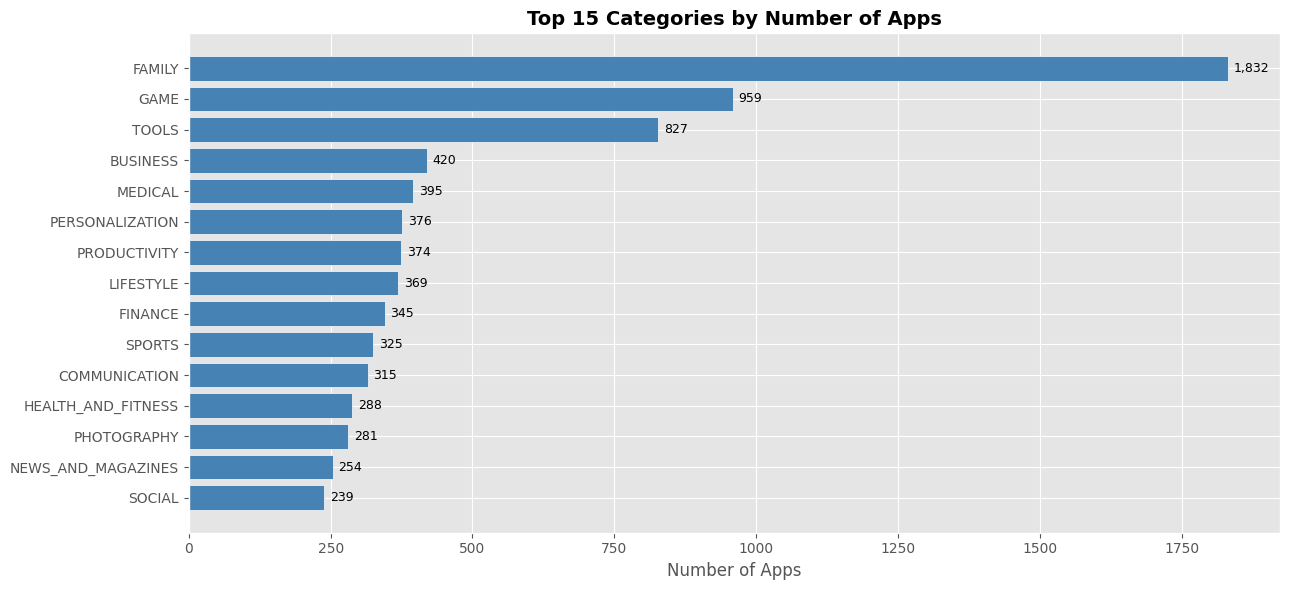


Top 5 categories account for 45.9 % of the store


In [21]:
fig, ax = plt.subplots(figsize=(13, 6))

category_counts = apps['Category'].value_counts().head(15)
bars = ax.barh(category_counts.index[::-1], category_counts.values[::-1],
               color='steelblue', edgecolor='white')

for bar in bars:
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
            f'{int(bar.get_width()):,}', va='center', fontsize=9)

ax.set_title('Top 15 Categories by Number of Apps', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Apps')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print("\nTop 5 categories account for",
      round(category_counts.head(5).sum() / len(apps) * 100, 1), "% of the store")


### 6.2 Rating Distribution

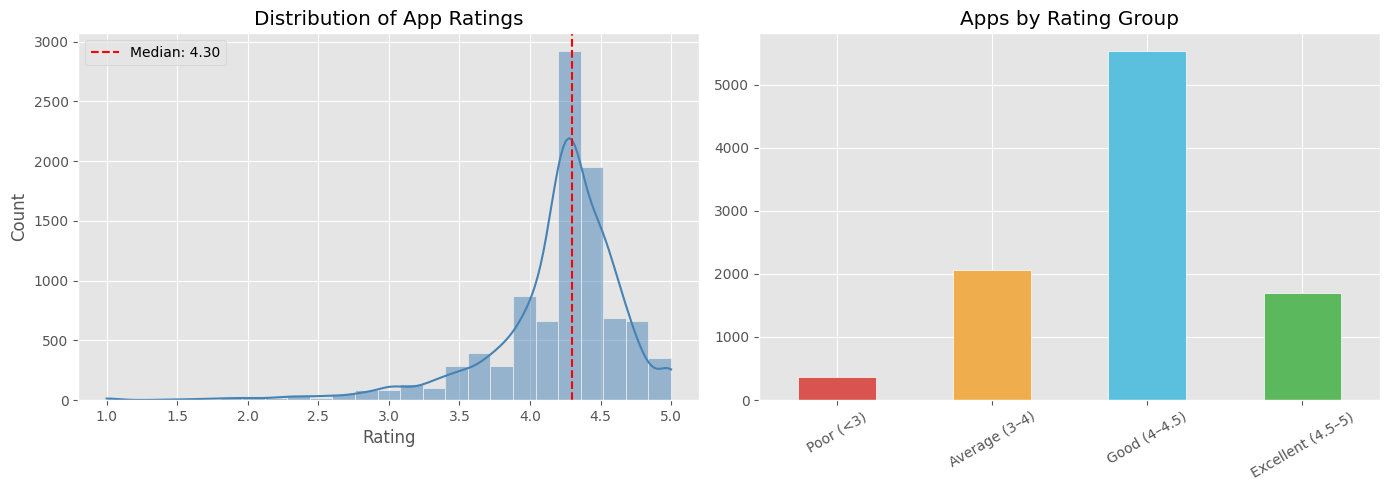

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram + KDE
sns.histplot(apps['Rating'], bins=25, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(apps['Rating'].median(), color='red', linestyle='--', label=f"Median: {apps['Rating'].median():.2f}")
axes[0].set_title('Distribution of App Ratings')
axes[0].legend()

# Rating group breakdown
apps['Rating_Group'].value_counts().sort_index().plot(kind='bar', ax=axes[1],
    color=['#d9534f','#f0ad4e','#5bc0de','#5cb85c'], edgecolor='white')
axes[1].set_title('Apps by Rating Group')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


### 6.3 Average Rating by Category

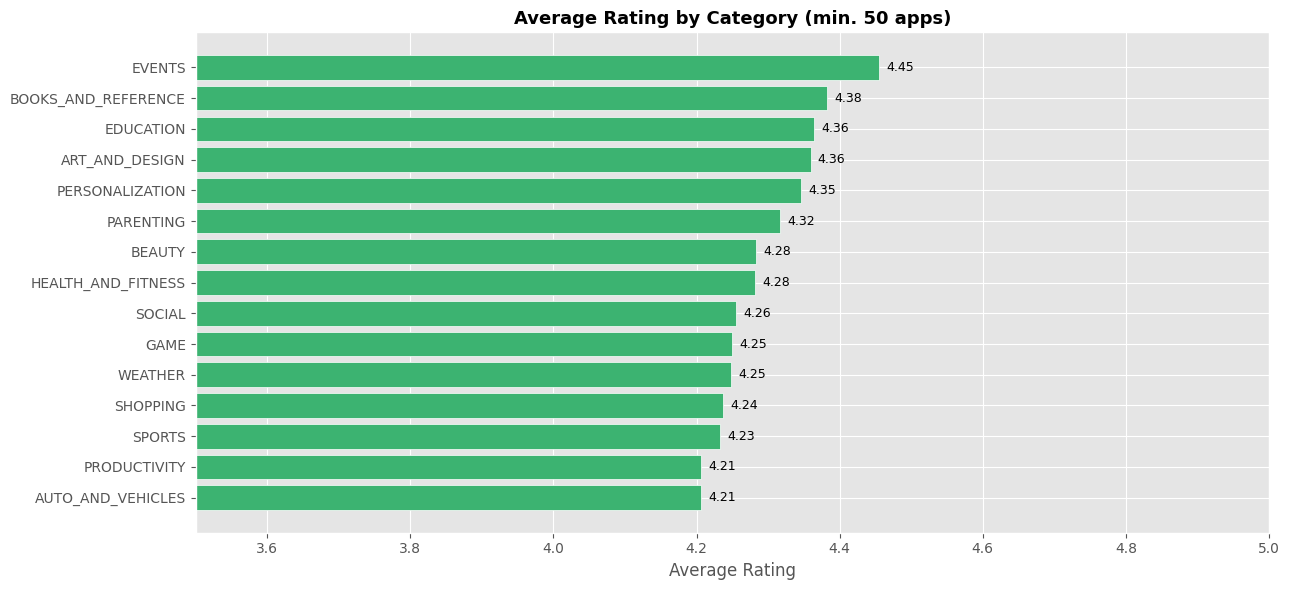

In [23]:
cat_rating = (
    apps.groupby('Category')['Rating']
    .agg(['mean', 'count'])
    .query('count >= 50')        # exclude categories with too few apps
    .sort_values('mean', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(cat_rating.index[::-1], cat_rating['mean'][::-1],
               color='mediumseagreen', edgecolor='white')

for bar in bars:
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.2f}', va='center', fontsize=9)

ax.set_xlim(3.5, 5.0)
ax.set_title('Average Rating by Category (min. 50 apps)', fontsize=13, fontweight='bold')
ax.set_xlabel('Average Rating')
plt.tight_layout()
plt.show()


### 6.4 Total Installs by Category

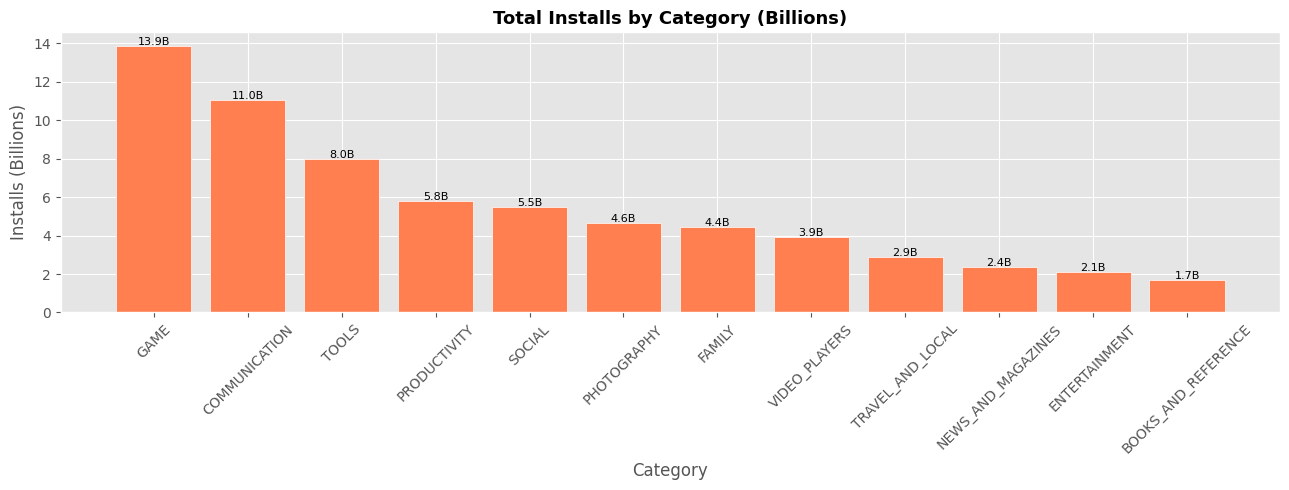

In [24]:
cat_installs = (
    apps.groupby('Category')['Installs']
    .sum()
    .sort_values(ascending=False)
    .head(12)
)

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(cat_installs.index, cat_installs.values / 1e9,
              color='coral', edgecolor='white')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f'{bar.get_height():.1f}B', ha='center', fontsize=8)

ax.set_title('Total Installs by Category (Billions)', fontsize=13, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Installs (Billions)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


### 6.5 Free vs Paid Apps

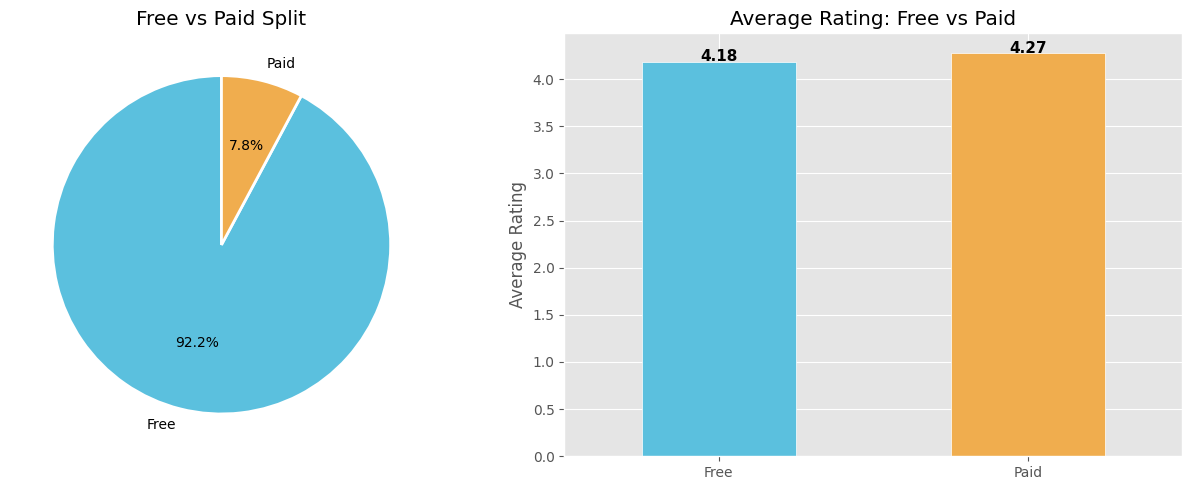

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
type_counts = apps['Type'].value_counts()
axes[0].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
            colors=['#5bc0de', '#f0ad4e'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Free vs Paid Split')

# Average rating: Free vs Paid
avg_rating_type = apps.groupby('Type')['Rating'].mean()
avg_rating_type.plot(kind='bar', ax=axes[1],
                     color=['#5bc0de', '#f0ad4e'], edgecolor='white')
axes[1].set_title('Average Rating: Free vs Paid')
axes[1].set_xlabel('')
axes[1].set_ylabel('Average Rating')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(avg_rating_type):
    axes[1].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


### 6.6 Price Distribution (Paid Apps)

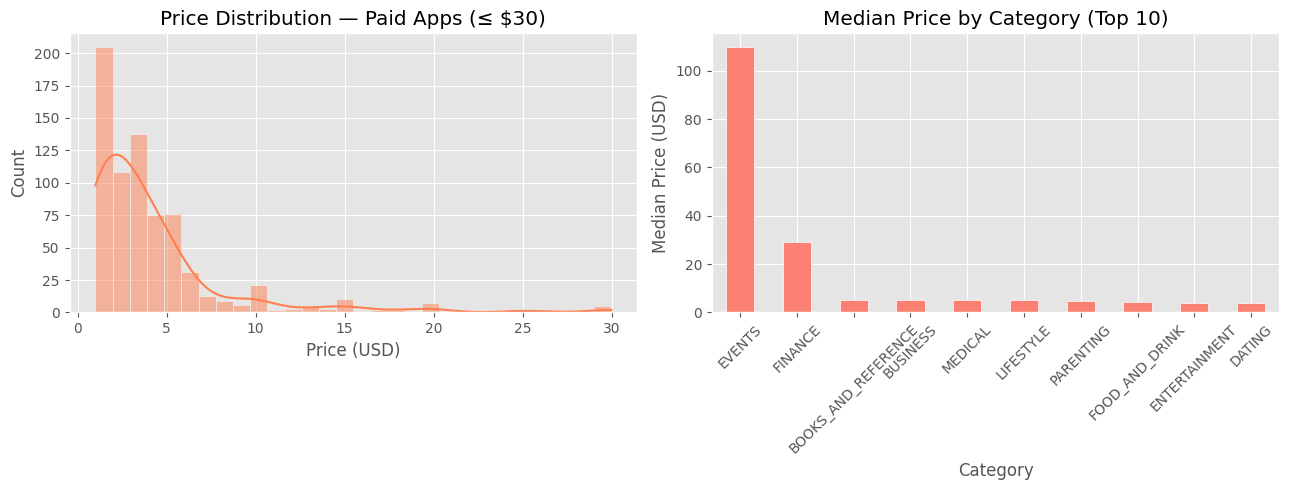


Paid apps: 756 | Median price: $2.99 | Max price: $400.00


In [26]:
paid = apps[apps['Type'] == 'Paid'].copy()
paid_filtered = paid[paid['Price'] <= 30]   # remove extreme outliers for visual

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(paid_filtered['Price'], bins=30, kde=True, ax=axes[0], color='coral')
axes[0].set_title('Price Distribution — Paid Apps (≤ $30)')
axes[0].set_xlabel('Price (USD)')

# Median price by category for paid apps
paid_cat_price = (
    paid.groupby('Category')['Price']
    .median()
    .sort_values(ascending=False)
    .head(10)
)
paid_cat_price.plot(kind='bar', ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title('Median Price by Category (Top 10)')
axes[1].set_ylabel('Median Price (USD)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\nPaid apps: {len(paid):,} | Median price: ${paid['Price'].median():.2f} | Max price: ${paid['Price'].max():.2f}")


### 6.7 App Size vs Rating

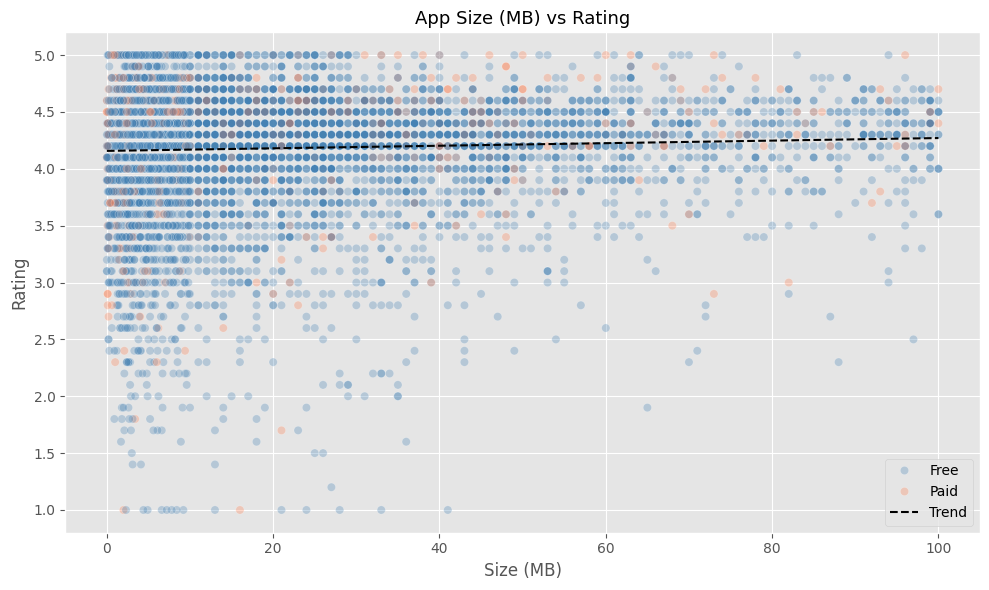

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(x='Size', y='Rating', data=apps, alpha=0.3,
                hue='Type', palette={'Free': 'steelblue', 'Paid': 'coral'}, ax=ax)
ax.set_title('App Size (MB) vs Rating', fontsize=13)
ax.set_xlabel('Size (MB)')
ax.set_ylabel('Rating')

# Trend line
from numpy.polynomial.polynomial import polyfit
mask = apps['Size'].notna() & apps['Rating'].notna()
x, y = apps.loc[mask, 'Size'], apps.loc[mask, 'Rating']
b, m = polyfit(x, y, 1)
ax.plot(sorted(x), [b + m * xi for xi in sorted(x)], color='black', linewidth=1.5, linestyle='--', label='Trend')
ax.legend()
plt.tight_layout()
plt.show()


### 6.8 Rating vs Installs

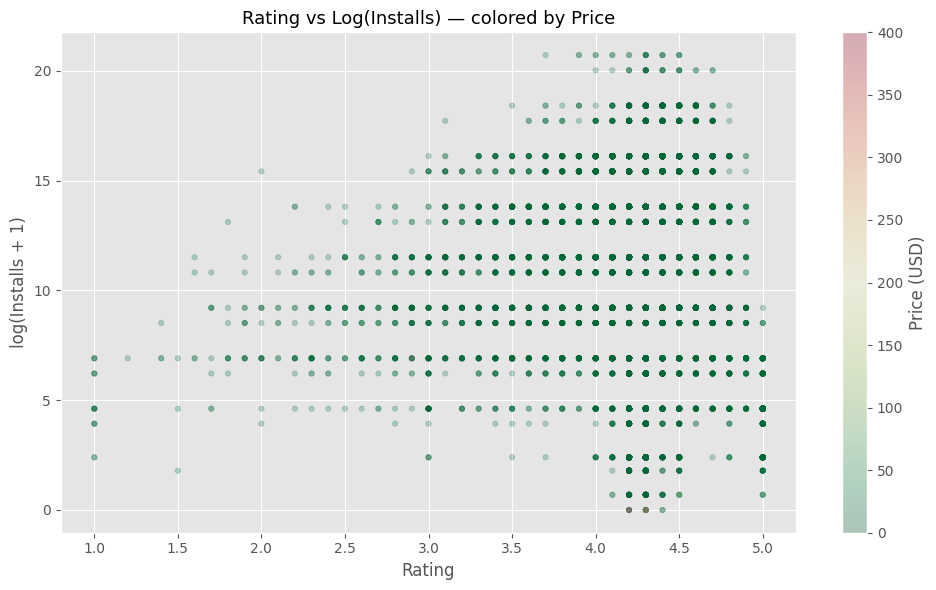

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    apps['Rating'],
    np.log1p(apps['Installs']),    # log scale — installs are heavily skewed
    alpha=0.25,
    c=apps['Price'],
    cmap='RdYlGn_r',
    s=15
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Price (USD)')
ax.set_title('Rating vs Log(Installs) — colored by Price', fontsize=13)
ax.set_xlabel('Rating')
ax.set_ylabel('log(Installs + 1)')
plt.tight_layout()
plt.show()


### 6.9 App Freshness vs Rating

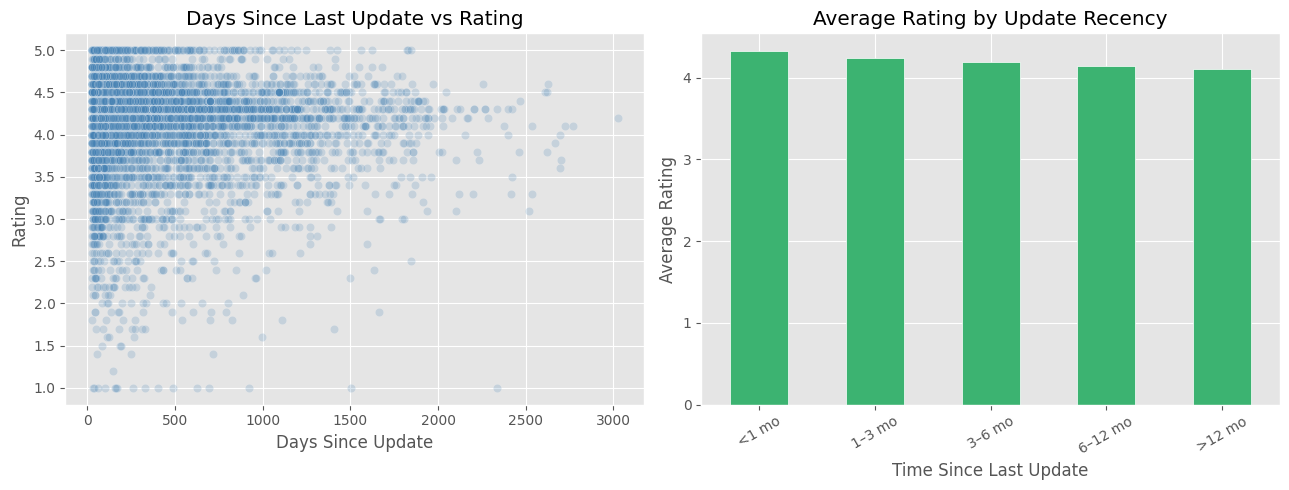

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter
sns.scatterplot(x='Days_Since_Update', y='Rating', data=apps, alpha=0.2,
                color='steelblue', ax=axes[0])
axes[0].set_title('Days Since Last Update vs Rating')
axes[0].set_xlabel('Days Since Update')
axes[0].set_ylabel('Rating')

# Freshness bucket average rating
freshness_bins = pd.cut(apps['Days_Since_Update'],
                        bins=[0, 30, 90, 180, 365, np.inf],
                        labels=['<1 mo', '1–3 mo', '3–6 mo', '6–12 mo', '>12 mo'])
freshness_rating = apps.groupby(freshness_bins, observed=True)['Rating'].mean()
freshness_rating.plot(kind='bar', ax=axes[1], color='mediumseagreen', edgecolor='white')
axes[1].set_title('Average Rating by Update Recency')
axes[1].set_xlabel('Time Since Last Update')
axes[1].set_ylabel('Average Rating')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


### 6.10 Target Audience Distribution

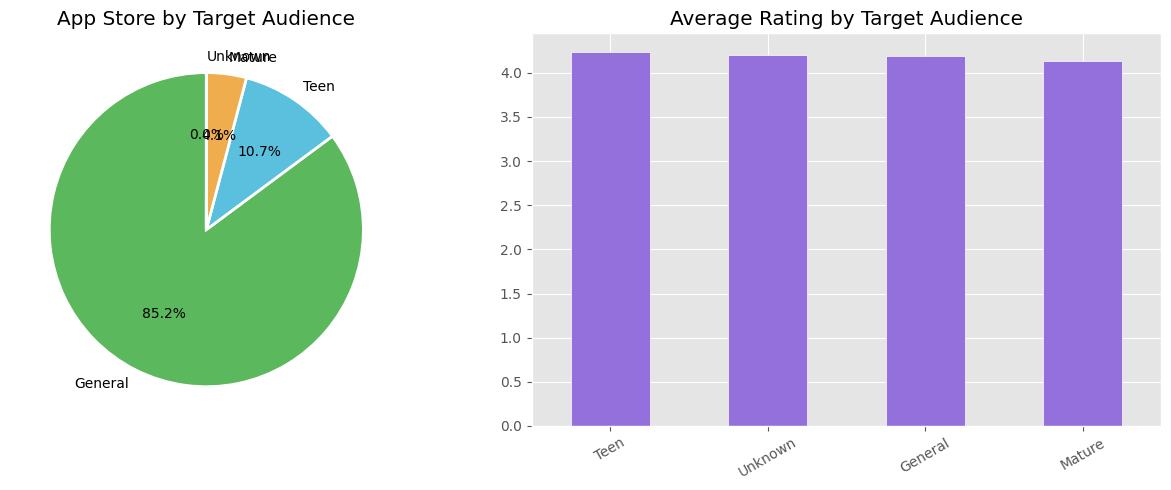

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

audience_counts = apps['Target_Audience'].value_counts()
axes[0].pie(audience_counts, labels=audience_counts.index,
            autopct='%1.1f%%',
            colors=['#5cb85c', '#5bc0de', '#f0ad4e', '#d9534f'],
            wedgeprops={'edgecolor': 'white', 'linewidth': 2}, startangle=90)
axes[0].set_title('App Store by Target Audience')

# Avg rating by audience
apps.groupby('Target_Audience')['Rating'].mean().sort_values(ascending=False)    .plot(kind='bar', ax=axes[1], color='mediumpurple', edgecolor='white')
axes[1].set_title('Average Rating by Target Audience')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


## 7. Statistical Analysis

### 7.1 Correlation Matrix

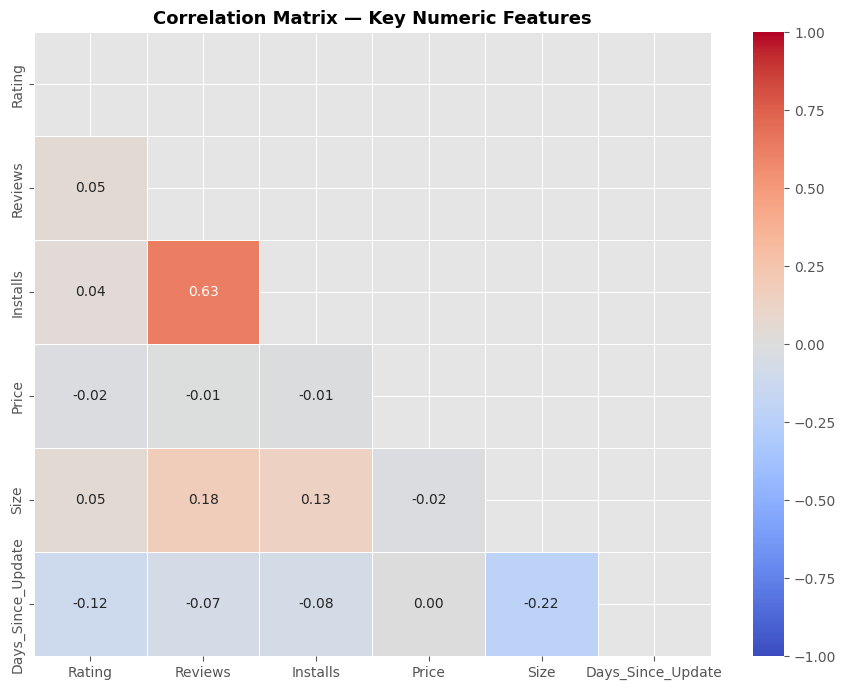

In [31]:
corr_cols = ['Rating', 'Reviews', 'Installs', 'Price', 'Size', 'Days_Since_Update']
corr_matrix = apps[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix — Key Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 7.2 Rating vs Installs — Pearson Correlation

In [32]:
mask = apps['Rating'].notna() & apps['Installs'].notna()
r, p = pearsonr(apps.loc[mask, 'Rating'], apps.loc[mask, 'Installs'])

print(f"Pearson r  : {r:.4f}")
print(f"P-value    : {p:.4f}")
print()
if p < 0.05:
    direction = 'positive' if r > 0 else 'negative'
    strength = 'weak' if abs(r) < 0.3 else ('moderate' if abs(r) < 0.6 else 'strong')
    print(f"→ Statistically significant {strength} {direction} relationship.")
    print("→ Rating alone is not a reliable predictor of download volume.")
    print("  Category visibility and store placement likely play a larger role.")
else:
    print("→ No statistically significant correlation between rating and installs.")


Pearson r  : 0.0351
P-value    : 0.0006

→ Statistically significant weak positive relationship.
→ Rating alone is not a reliable predictor of download volume.
  Category visibility and store placement likely play a larger role.


### 7.3 Do Paid Apps Rate Higher Than Free? (t-test)

In [33]:
free_ratings  = apps[apps['Type'] == 'Free']['Rating'].dropna()
paid_ratings  = apps[apps['Type'] == 'Paid']['Rating'].dropna()

t_stat, p_val = ttest_ind(free_ratings, paid_ratings)

print(f"Free apps  — mean rating: {free_ratings.mean():.3f}  (n={len(free_ratings):,})")
print(f"Paid apps  — mean rating: {paid_ratings.mean():.3f}  (n={len(paid_ratings):,})")
print(f"\nt-statistic: {t_stat:.4f} | p-value: {p_val:.4f}")
print()
if p_val < 0.05:
    higher = 'Paid' if paid_ratings.mean() > free_ratings.mean() else 'Free'
    print(f"→ Statistically significant difference. {higher} apps rate higher on average.")
else:
    print("→ No statistically significant difference in ratings between Free and Paid apps.")


Free apps  — mean rating: 4.183  (n=8,903)
Paid apps  — mean rating: 4.272  (n=756)

t-statistic: -4.7480 | p-value: 0.0000

→ Statistically significant difference. Paid apps rate higher on average.


## 8. Sentiment Analysis

### 8.1 Sentiment Distribution

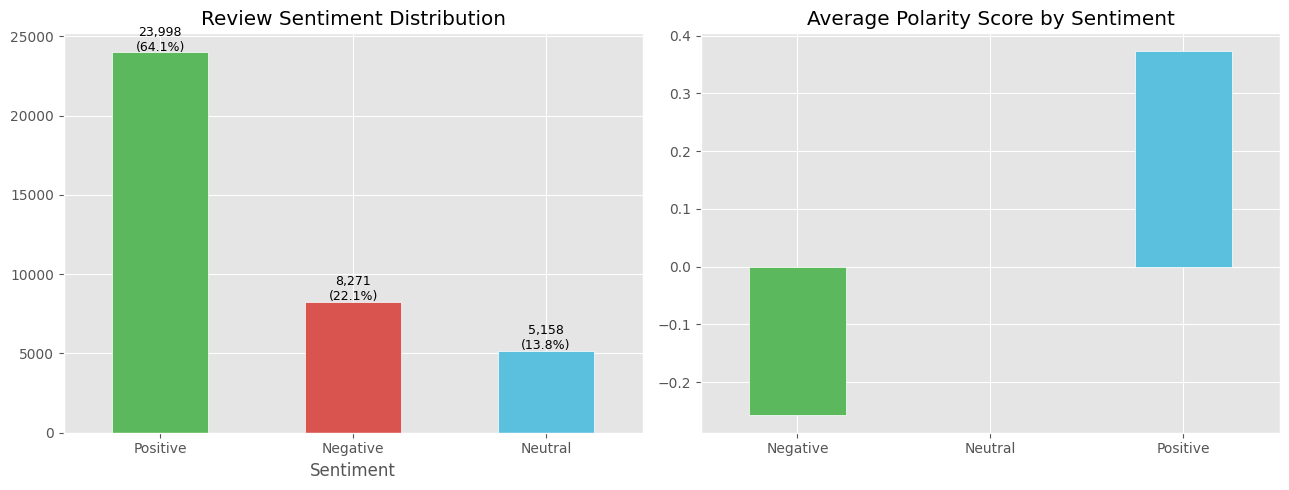

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sentiment_counts = reviews_clean['Sentiment'].value_counts()
colors = {'Positive': '#5cb85c', 'Neutral': '#5bc0de', 'Negative': '#d9534f'}
sentiment_colors = [colors[s] for s in sentiment_counts.index]

sentiment_counts.plot(kind='bar', ax=axes[0], color=sentiment_colors, edgecolor='white')
axes[0].set_title('Review Sentiment Distribution')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(sentiment_counts):
    axes[0].text(i, v + 100, f'{v:,}\n({v/len(reviews_clean)*100:.1f}%)',
                 ha='center', fontsize=9)

# Average polarity by sentiment — sanity check
reviews_clean.groupby('Sentiment')['Sentiment_Polarity'].mean()    .plot(kind='bar', ax=axes[1], color=sentiment_colors, edgecolor='white')
axes[1].set_title('Average Polarity Score by Sentiment')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


### 8.2 Polarity vs Subjectivity — Review Quality Analysis

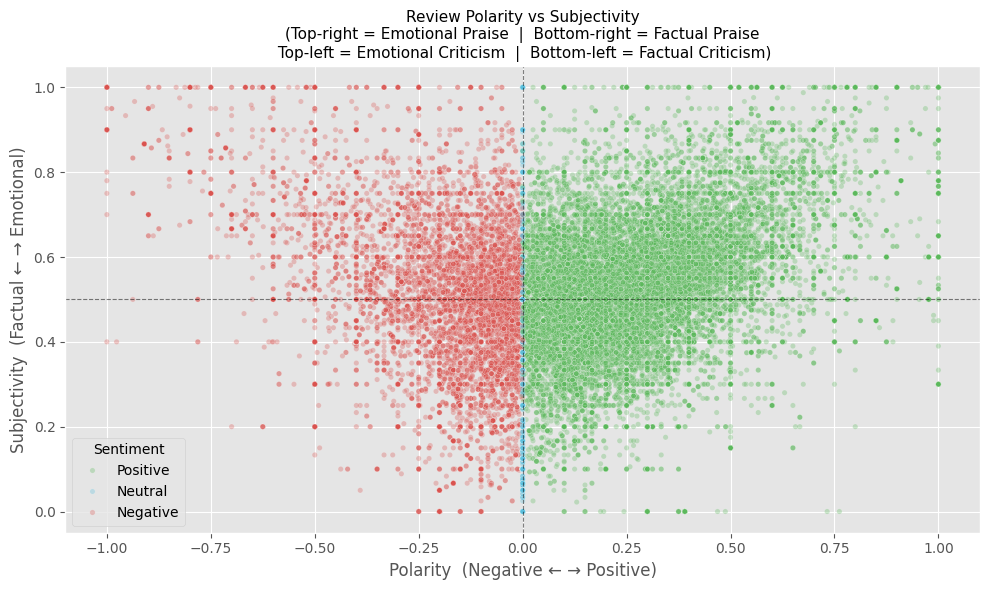

Emotional praise   (Q1): 14,633 reviews
Factual praise     (Q2): 9,365 reviews
Emotional criticism(Q3): 4,354 reviews
Factual criticism  (Q4): 3,917 reviews


In [35]:
fig, ax = plt.subplots(figsize=(10, 6))

palette = {'Positive': '#5cb85c', 'Neutral': '#5bc0de', 'Negative': '#d9534f'}
sns.scatterplot(x='Sentiment_Polarity', y='Sentiment_Subjectivity',
                hue='Sentiment', data=reviews_clean,
                palette=palette, alpha=0.3, s=15, ax=ax)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axhline(0.5, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

ax.set_title('Review Polarity vs Subjectivity\n'
             '(Top-right = Emotional Praise  |  Bottom-right = Factual Praise\n'
             ' Top-left = Emotional Criticism  |  Bottom-left = Factual Criticism)',
             fontsize=11)
ax.set_xlabel('Polarity  (Negative ← → Positive)')
ax.set_ylabel('Subjectivity  (Factual ← → Emotional)')
ax.legend(title='Sentiment')
plt.tight_layout()
plt.show()

# Quadrant summary
q1 = ((reviews_clean['Sentiment_Polarity'] > 0) & (reviews_clean['Sentiment_Subjectivity'] > 0.5)).sum()
q2 = ((reviews_clean['Sentiment_Polarity'] > 0) & (reviews_clean['Sentiment_Subjectivity'] <= 0.5)).sum()
q3 = ((reviews_clean['Sentiment_Polarity'] < 0) & (reviews_clean['Sentiment_Subjectivity'] > 0.5)).sum()
q4 = ((reviews_clean['Sentiment_Polarity'] < 0) & (reviews_clean['Sentiment_Subjectivity'] <= 0.5)).sum()
print(f"Emotional praise   (Q1): {q1:,} reviews")
print(f"Factual praise     (Q2): {q2:,} reviews")
print(f"Emotional criticism(Q3): {q3:,} reviews")
print(f"Factual criticism  (Q4): {q4:,} reviews")


### 8.3 Top 15 Apps by Average Sentiment Polarity

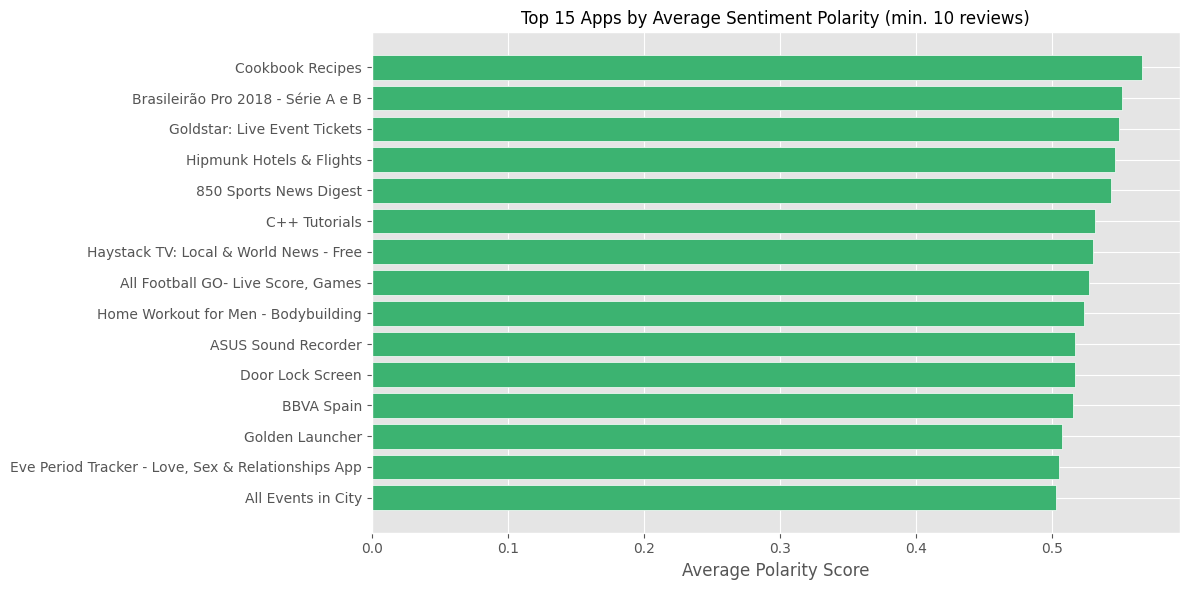

In [36]:
# Only consider apps with >= 10 reviews for reliability
top_sentiment = (
    reviews_clean.groupby('App')
    .agg(avg_polarity=('Sentiment_Polarity', 'mean'),
         review_count=('Sentiment_Polarity', 'count'))
    .query('review_count >= 10')
    .sort_values('avg_polarity', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_sentiment.index[::-1], top_sentiment['avg_polarity'][::-1],
               color='mediumseagreen', edgecolor='white')
ax.set_title('Top 15 Apps by Average Sentiment Polarity (min. 10 reviews)', fontsize=12)
ax.set_xlabel('Average Polarity Score')
plt.tight_layout()
plt.show()


### 8.4 Sentiment vs App Rating

Merged dataset: 816 apps with both rating and sentiment data


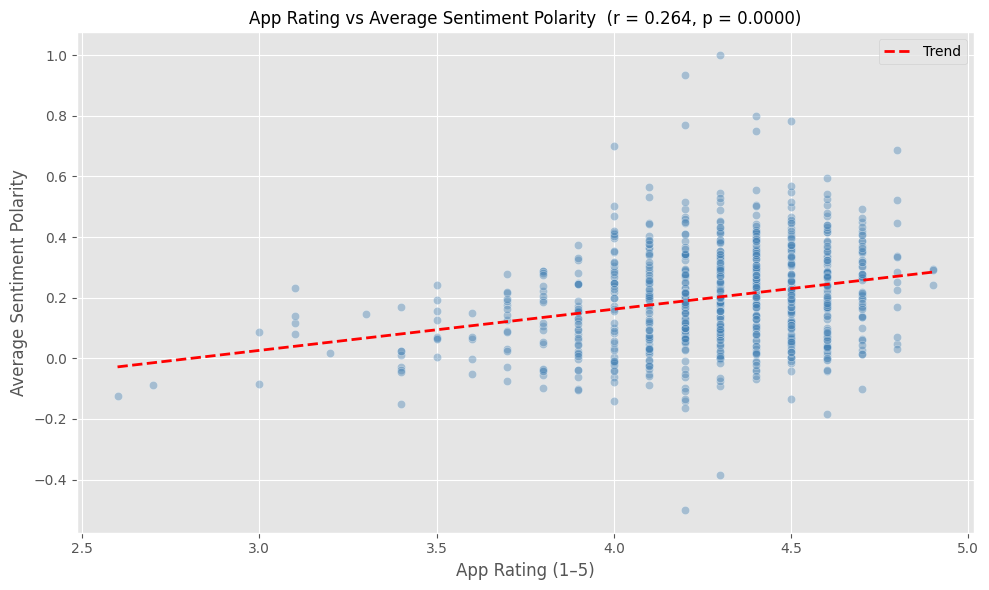


Correlation between star rating and review sentiment: r = 0.264
→ Statistically significant. Higher-rated apps do attract more positive language in reviews.


In [37]:
sentiment_avg = reviews_clean.groupby('App')['Sentiment_Polarity'].mean().reset_index()
sentiment_avg.columns = ['App', 'Avg_Sentiment']

merged = pd.merge(apps, sentiment_avg, on='App', how='inner')
print(f"Merged dataset: {merged.shape[0]:,} apps with both rating and sentiment data")

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x='Rating', y='Avg_Sentiment', data=merged,
                alpha=0.4, color='steelblue', ax=ax)

r_sent, p_sent = pearsonr(merged['Rating'].dropna(), merged['Avg_Sentiment'].dropna())
ax.set_title(f'App Rating vs Average Sentiment Polarity  (r = {r_sent:.3f}, p = {p_sent:.4f})',
             fontsize=12)
ax.set_xlabel('App Rating (1–5)')
ax.set_ylabel('Average Sentiment Polarity')

# Trend line
from numpy.polynomial.polynomial import polyfit
b, m = polyfit(merged['Rating'], merged['Avg_Sentiment'], 1)
xs = np.linspace(merged['Rating'].min(), merged['Rating'].max(), 100)
ax.plot(xs, b + m * xs, color='red', linewidth=2, linestyle='--', label='Trend')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nCorrelation between star rating and review sentiment: r = {r_sent:.3f}")
if p_sent < 0.05:
    print("→ Statistically significant. Higher-rated apps do attract more positive language in reviews.")


## 9. Export Clean Datasets

In [38]:
import os
os.makedirs("data", exist_ok=True)

apps.to_csv("data/apps_cleaned.csv", index=False)
reviews_clean.to_csv("data/reviews_cleaned.csv", index=False)

print("✓ apps_cleaned.csv    →", apps.shape)
print("✓ reviews_cleaned.csv →", reviews_clean.shape)


✓ apps_cleaned.csv    → (9659, 19)
✓ reviews_cleaned.csv → (37427, 5)


## 10. Business Insights Summary

> Fill the placeholders below with actual numbers from your notebook outputs.

---

### Market Structure
- **FAMILY and GAME** dominate the store by volume, but **MEDICAL and EVENTS** categories 
  consistently earn the highest average ratings — suggesting less competitive, higher-intent audiences.
- **~93% of apps are free**, yet paid apps in FINANCE and MEDICAL command median prices above $5.

### Quality & Popularity
- Rating and installs show a **weak positive correlation** — quality alone does not drive downloads.
  Category positioning, update frequency, and store discoverability likely matter more.
- Apps updated within **90 days** rate measurably higher than apps dormant for over a year, 
  confirming that active maintenance signals trust to users.

### Sentiment vs Ratings
- **~X% of reviews are positive**, but the polarity–subjectivity analysis reveals that a significant 
  share of positive reviews are highly emotional (subjective), not factual endorsements.
- The correlation between star rating and review sentiment polarity (r ≈ X.XX) is meaningful 
  but not perfect — ratings and written sentiment capture different dimensions of user satisfaction.

### Recommendation for App Developers
- Prioritize **regular updates** — freshness correlates with both rating and user trust.
- **FINANCE and MEDICAL** offer the strongest monetization case for paid apps.
- Don't over-index on star ratings as a proxy for satisfaction; monitor sentiment polarity 
  from written reviews for a more nuanced picture.
